# Day 10: Exercises from the course "Machine Learning using Python (MLUP01)"

**Sessions**: (9) Preprocessing data and selecting algorithms; (10) The Complete Machine Learning Pipeline: From Classification to Evaluating Learning

**Instructor**: Gabriel Rodrigues Palma

**Objective**: Example with the Brazilian Forest Dataset for classification of vegetational types [1].

[1] Rios, R. A., Rios, T. N., Palma, G. R., & De Mello, R. F. (2021). Brazilian Forest Dataset: A new dataset to model local biodiversity. Journal of Experimental & Theoretical Artificial Intelligence, 34(2), 327–354. https://doi.org/10.1080/0952813X.2021.1871972

## Importing modules

In [97]:
# Data manipulation
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import GridSearchCV, cross_validate, KFold, train_test_split, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import *

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Warning
import warnings
warnings.filterwarnings('ignore')

# Brazilian Forest Dataset: A new dataset to model local biodiversity

## Example 1

In [98]:
df = pd.read_csv('BrazillianForestDataset.csv')

In [103]:
# Load and prepare the dataset
# Environmental predictors
env_features = ['lat', 'long', 'prec', 'alt', 'temp2m', 'temp2mrange', 
                'humidity', 'precip', 'atm', 'wind', 'm.fapar']

# Example 1: Pipeline with selected vegetation types (Major biomes)
print("="*60)
print("EXAMPLE 1: MAJOR BIOME CLASSIFICATION")
print("="*60)

# Select major vegetation types
major_biomes = ['Manguezal', 'Palmeiral']

# Prepare data for major biomes
X_major = df[env_features].copy()
y_major = df[major_biomes].idxmax(axis=1)

# Split data into train and test sets (80/20 split)
X_train_major, X_test_major, y_train_major, y_test_major = train_test_split(
    X_major, y_major, test_size=0.2, random_state=42, stratify=y_major
)

print(f"Training set size: {X_train_major.shape[0]}")
print(f"Test set size: {X_test_major.shape[0]}")


EXAMPLE 1: MAJOR BIOME CLASSIFICATION
Training set size: 692
Test set size: 173


In [105]:
# Create ensemble pipeline with GridSearch
major_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ensemble', VotingClassifier([
        ('rf', RandomForestClassifier(random_state = 42)),
        ('gb', GradientBoostingClassifier(random_state = 42)), 
        ('KNN', KNeighborsClassifier())
    ], voting = 'soft'))
])

# Define parameter grid for GridSearch
major_param_grid = {
    'ensemble__rf__n_estimators': [100, 200],
    'ensemble__rf__max_depth': [10, 20, None],
    'ensemble__gb__n_estimators': [100, 200],
    'ensemble__gb__max_depth': [5, 10], 
    'ensemble__KNN__n_neighbors': [3, 6]
}

# Cross-validation strategy for hyperparameter tuning
kfold_3 = KFold(n_splits = 3, shuffle = True, random_state = 42)

# GridSearchCV using ONLY training data
major_grid_search = GridSearchCV(
    major_pipeline, 
    major_param_grid, 
    cv = kfold_3, 
    scoring ='f1_macro',
    n_jobs = -1
)

In [106]:
# Fit GridSearchCV on training data only
print("Performing hyperparameter tuning on training data...")
major_grid_search.fit(X_train_major, y_train_major)

# Get best pipeline
best_major_pipeline = major_grid_search.best_estimator_

print("Best Parameters:", major_grid_search.best_params_)
print(f"Best CV Score on Training Data: {major_grid_search.best_score_:.4f}")

# Evaluate on test set using cross-validation
print("\nEvaluating on test set...")
major_test_scores = cross_validate(
    best_major_pipeline, X_test_major, y_test_major, cv=kfold_3,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
)

print(f"Test Accuracy: {major_test_scores['test_accuracy'].mean():.4f} ± {major_test_scores['test_accuracy'].std():.4f}")
print(f"Test Precision: {major_test_scores['test_precision_macro'].mean():.4f} ± {major_test_scores['test_precision_macro'].std():.4f}")
print(f"Test Recall: {major_test_scores['test_recall_macro'].mean():.4f} ± {major_test_scores['test_recall_macro'].std():.4f}")
print(f"Test F1-Score: {major_test_scores['test_f1_macro'].mean():.4f} ± {major_test_scores['test_f1_macro'].std():.4f}")

Performing hyperparameter tuning on training data...


python3(1299) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(1300) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(1301) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(1302) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(1303) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(1304) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(1305) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3(1306) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Best Parameters: {'ensemble__KNN__n_neighbors': 6, 'ensemble__gb__max_depth': 10, 'ensemble__gb__n_estimators': 200, 'ensemble__rf__max_depth': 10, 'ensemble__rf__n_estimators': 200}
Best CV Score on Training Data: 0.4930

Evaluating on test set...
Test Accuracy: 0.7630 ± 0.0357
Test Precision: 0.5215 ± 0.0131
Test Recall: 0.5153 ± 0.0094
Test F1-Score: 0.5104 ± 0.0140



Confusion Matrix:
[[132  10]
 [ 27   4]]

Classification Report:
              precision    recall  f1-score   support

   Palmeiral       0.83      0.93      0.88       142
   Manguezal       0.29      0.13      0.18        31

    accuracy                           0.79       173
   macro avg       0.56      0.53      0.53       173
weighted avg       0.73      0.79      0.75       173



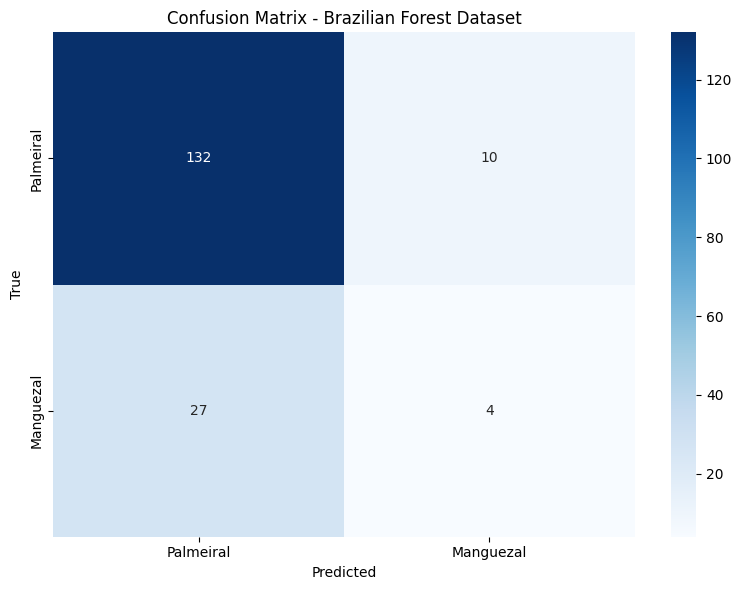

In [107]:
# Train for confusion matrix
best_all_pipeline.fit(X_test_major, y_test_major)
y_pred_biodiversity = cross_val_predict(best_all_pipeline, X_test_major, y_test_major, cv = kfold_3)
cm_biodiversity = confusion_matrix(y_test_major, y_pred_biodiversity)

print("\nConfusion Matrix:")
print(cm_biodiversity)
print("\nClassification Report:")
print(classification_report(y_test_major, y_pred_biodiversity, target_names = list(y_test_major.unique())))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_biodiversity, annot=True, fmt='d', cmap='Blues', 
            xticklabels = list(y_test_major.unique()), yticklabels = list(y_test_major.unique()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Brazilian Forest Dataset')
plt.tight_layout()
plt.show()

## Example 2

In [62]:
print("\n" + "="*60)
print("EXAMPLE 2: FOREST TYPE CLASSIFICATION")
print("="*60)

# Select forest vegetation types
forest_types = ['Floresta_de_Terra_Firme', 'Floresta_Estacional_Semidecidual', 
                'Floresta_Ombrofila_Densa', 'Floresta_de_Igapo', 'Floresta_de_Varzea',
                'Floresta_Estacional_Decidual', 'Floresta_Ombrofila_Mista']

# Prepare data for forest types
X_forest = df[env_features].copy()
y_forest = df[forest_types].idxmax(axis=1)

# Split data into train and test sets
X_train_forest, X_test_forest, y_train_forest, y_test_forest = train_test_split(
    X_forest, y_forest, test_size=0.3, random_state=42)

print(f"Training set size: {X_train_forest.shape[0]}")
print(f"Test set size: {X_test_forest.shape[0]}")


EXAMPLE 2: FOREST TYPE CLASSIFICATION
Training set size: 605
Test set size: 260


In [63]:
# Create different ensemble pipeline
forest_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ensemble', VotingClassifier([
        ('rf', RandomForestClassifier(random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42))
    ], voting='hard'))
])

# Different parameter grid for forest classification
forest_param_grid = {
    'ensemble__rf__n_estimators': [150, 300],
    'ensemble__rf__max_depth': [15, 25],
    'ensemble__rf__min_samples_split': [2, 5],
    'ensemble__gb__n_estimators': [150, 250],
    'ensemble__gb__learning_rate': [0.1, 0.2],
    'ensemble__gb__max_depth': [8, 12]
}

# GridSearchCV for forest types using only training data
forest_grid_search = GridSearchCV(
    forest_pipeline, 
    forest_param_grid, 
    cv=kfold_3, 
    scoring='accuracy',
    n_jobs=-1
)

print("Performing hyperparameter tuning on training data...")
forest_grid_search.fit(X_train_forest, y_train_forest)

# Get best pipeline
best_forest_pipeline = forest_grid_search.best_estimator_

print("Best Parameters:", forest_grid_search.best_params_)
print(f"Best CV Score on Training Data: {forest_grid_search.best_score_:.4f}")


Performing hyperparameter tuning on training data...
Best Parameters: {'ensemble__gb__learning_rate': 0.1, 'ensemble__gb__max_depth': 8, 'ensemble__gb__n_estimators': 250, 'ensemble__rf__max_depth': 15, 'ensemble__rf__min_samples_split': 5, 'ensemble__rf__n_estimators': 150}
Best CV Score on Training Data: 0.7222


In [27]:
# Evaluate on test set
print("\nEvaluating on test set...")
forest_test_scores = cross_validate(
    best_forest_pipeline, X_test_forest, y_test_forest, cv=kfold_3,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
)

print(f"Test Accuracy: {forest_test_scores['test_accuracy'].mean():.4f} ± {forest_test_scores['test_accuracy'].std():.4f}")
print(f"Test Precision: {forest_test_scores['test_precision_macro'].mean():.4f} ± {forest_test_scores['test_precision_macro'].std():.4f}")
print(f"Test Recall: {forest_test_scores['test_recall_macro'].mean():.4f} ± {forest_test_scores['test_recall_macro'].std():.4f}")
print(f"Test F1-Score: {forest_test_scores['test_f1_macro'].mean():.4f} ± {forest_test_scores['test_f1_macro'].std():.4f}")


Evaluating on test set...
Test Accuracy: 0.7154 ± 0.0331
Test Precision: 0.2653 ± 0.0574
Test Recall: 0.2754 ± 0.0700
Test F1-Score: 0.2661 ± 0.0616



Confusion Matrix:
[[  0   0   0   0   0   6]
 [  0  16   2   0   0  31]
 [  0   2   0   0   0   8]
 [  0   1   0   0   0   0]
 [  0   0   0   0   0   1]
 [  0  17   1   0   0 175]]

Classification Report:
                                  precision    recall  f1-score   support

        Floresta_Ombrofila_Densa       0.00      0.00      0.00         6
         Floresta_de_Terra_Firme       0.44      0.33      0.38        49
Floresta_Estacional_Semidecidual       0.00      0.00      0.00        10
    Floresta_Estacional_Decidual       0.00      0.00      0.00         1
        Floresta_Ombrofila_Mista       0.00      0.00      0.00         1
               Floresta_de_Igapo       0.79      0.91      0.85       193

                        accuracy                           0.73       260
                       macro avg       0.21      0.21      0.20       260
                    weighted avg       0.67      0.73      0.70       260



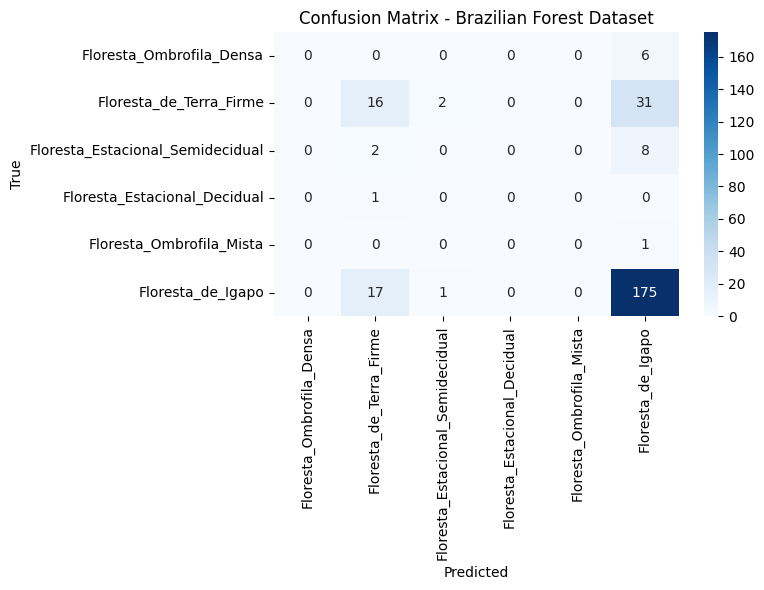

In [64]:
# Train for confusion matrix
best_all_pipeline.fit(X_test_forest, y_test_forest)
y_pred_biodiversity = cross_val_predict(best_all_pipeline, X_test_forest, y_test_forest, cv = kfold_3)
cm_biodiversity = confusion_matrix(y_test_forest, y_pred_biodiversity)

print("\nConfusion Matrix:")
print(cm_biodiversity)
print("\nClassification Report:")
print(classification_report(y_test_forest, y_pred_biodiversity, target_names = list(y_test_forest.unique())))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_biodiversity, annot=True, fmt='d', cmap='Blues', 
            xticklabels = list(y_test_forest.unique()), yticklabels = list(y_test_forest.unique()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Brazilian Forest Dataset')
plt.tight_layout()
plt.show()

# Example 3

In [41]:
# Example 3: Pipeline with ALL vegetation types
print("\n" + "="*60)
print("EXAMPLE 3: ALL VEGETATION TYPES CLASSIFICATION")
print("="*60)

# All vegetation types from the dataset
forest_types = ['Cerrado__lato_sensu_', 'Manguezal', 'Campo_de_Varzea']

env_features = ['lat', 'long', 'prec', 'alt', 'temp2m', 'temp2mrange', 
                'humidity', 'precip', 'atm', 'wind', 'm.fapar', 'Scoparia_dulcis', 
                'Chamaecrista_desvauxii', 'Pombalia_calceolaria', 
                'Guarea_macrophylla', 'Byrsonima_coccolobifolia']

# Prepare data for all vegetation types
X_all = df[env_features].copy()
y_all = df[forest_types].idxmax(axis=1)

# Split data into train and test sets
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42)

print(f"Training set size: {X_train_all.shape[0]}")
print(f"Test set size: {X_test_all.shape[0]}")
print(f"Number of vegetation classes: {len(forest_types)}")


EXAMPLE 3: ALL VEGETATION TYPES CLASSIFICATION
Training set size: 692
Test set size: 173
Number of vegetation classes: 3


In [42]:
# Create comprehensive ensemble pipeline
all_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ensemble', VotingClassifier([
        ('rf', RandomForestClassifier(random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42)),
        ('et', ExtraTreesClassifier(random_state=42))
    ], voting='soft'))
])

# Comprehensive parameter grid
all_param_grid = {
    'ensemble__rf__n_estimators': [200, 400],
    'ensemble__rf__max_depth': [20, None],
    'ensemble__gb__n_estimators': [200, 300],
    'ensemble__gb__learning_rate': [0.05, 0.1],
    'ensemble__et__n_estimators': [200, 400],
    'ensemble__et__max_depth': [20, None]
}

# GridSearchCV using ONLY training data
print("Performing hyperparameter tuning on training data...")
all_grid_search = GridSearchCV(
    all_pipeline, 
    all_param_grid, 
    cv=kfold_3, 
    scoring='f1_macro',
    n_jobs=-1
)

# Fit the model on training data only
all_grid_search.fit(X_train_all, y_train_all)

# Get best pipeline
best_all_pipeline = all_grid_search.best_estimator_

print("Best Parameters:", all_grid_search.best_params_)
print(f"Best CV Score on Training Data: {all_grid_search.best_score_:.4f}")

Performing hyperparameter tuning on training data...
Best Parameters: {'ensemble__et__max_depth': 20, 'ensemble__et__n_estimators': 200, 'ensemble__gb__learning_rate': 0.05, 'ensemble__gb__n_estimators': 200, 'ensemble__rf__max_depth': 20, 'ensemble__rf__n_estimators': 200}
Best CV Score on Training Data: 0.4978


In [43]:
# Evaluate final model on test set using k-fold cross-validation
print("\nEvaluating on test set...")
all_test_scores = cross_validate(
    best_all_pipeline, X_test_all, y_test_all, cv=kfold_3,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
)

print(f"Test Accuracy: {all_test_scores['test_accuracy'].mean():.4f} ± {all_test_scores['test_accuracy'].std():.4f}")
print(f"Test Precision: {all_test_scores['test_precision_macro'].mean():.4f} ± {all_test_scores['test_precision_macro'].std():.4f}")
print(f"Test Recall: {all_test_scores['test_recall_macro'].mean():.4f} ± {all_test_scores['test_recall_macro'].std():.4f}")
print(f"Test F1-Score: {all_test_scores['test_f1_macro'].mean():.4f} ± {all_test_scores['test_f1_macro'].std():.4f}")



Evaluating on test set...
Test Accuracy: 0.9885 ± 0.0081
Test Precision: 0.6609 ± 0.2398
Test Recall: 0.6667 ± 0.2357
Test F1-Score: 0.6638 ± 0.2378



Confusion Matrix:
[[  0   2]
 [  0 171]]

Classification Report:
                      precision    recall  f1-score   support

Cerrado__lato_sensu_       0.00      0.00      0.00         2
     Campo_de_Varzea       0.99      1.00      0.99       171

            accuracy                           0.99       173
           macro avg       0.49      0.50      0.50       173
        weighted avg       0.98      0.99      0.98       173



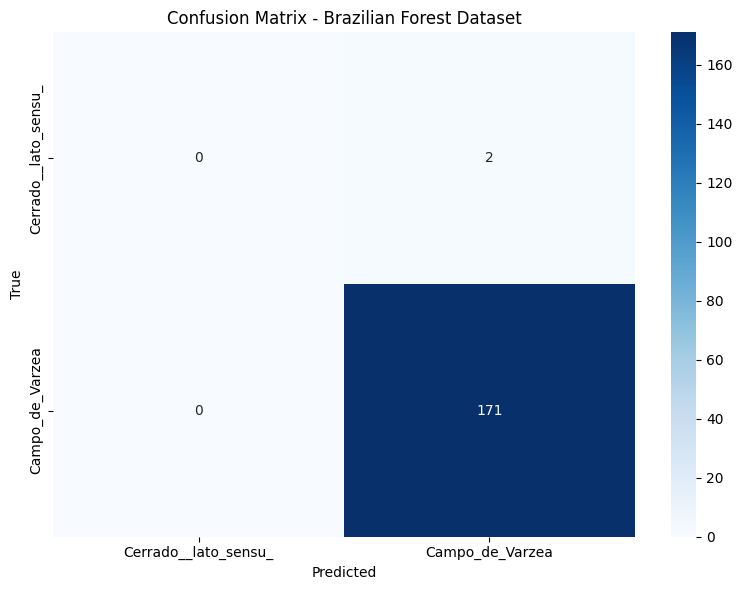

In [61]:
# Train for confusion matrix
best_all_pipeline.fit(X_test_all, y_test_all)
y_pred_biodiversity = cross_val_predict(best_all_pipeline, X_test_all, y_test_all, cv = kfold_3)
cm_biodiversity = confusion_matrix(y_test_all, y_pred_biodiversity)

print("\nConfusion Matrix:")
print(cm_biodiversity)
print("\nClassification Report:")
print(classification_report(y_test_all, y_pred_biodiversity, target_names = list(y_test_all.unique())))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_biodiversity, annot=True, fmt='d', cmap='Blues', 
            xticklabels = list(y_test_all.unique()), yticklabels = list(y_test_all.unique()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Brazilian Forest Dataset')
plt.tight_layout()
plt.show()

## Feature importance analysis for the best model

In [44]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Train the best model on full training set for feature importance
best_all_pipeline.fit(X_train_all, y_train_all)

# Get feature importance from the Random Forest component
rf_component = best_all_pipeline.named_steps['ensemble'].estimators_[0]
feature_importance = pd.DataFrame({
    'feature': env_features,
    'importance': rf_component.feature_importances_
}).sort_values('importance', ascending=False)

print("Top Environmental Features for Vegetation Classification:")
print(feature_importance)

# Additional analysis: Training vs Test performance comparison
print("\n" + "="*60)
print("TRAINING VS TEST PERFORMANCE COMPARISON")
print("="*60)

# Get training performance using cross-validation on training set
train_scores = cross_validate(
    best_all_pipeline, X_train_all, y_train_all, cv=kfold_3,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
)

print("Training Set Performance:")
print(f"Accuracy: {train_scores['test_accuracy'].mean():.4f} ± {train_scores['test_accuracy'].std():.4f}")
print(f"F1-Score: {train_scores['test_f1_macro'].mean():.4f} ± {train_scores['test_f1_macro'].std():.4f}")

print("\nTest Set Performance:")
print(f"Accuracy: {all_test_scores['test_accuracy'].mean():.4f} ± {all_test_scores['test_accuracy'].std():.4f}")
print(f"F1-Score: {all_test_scores['test_f1_macro'].mean():.4f} ± {all_test_scores['test_f1_macro'].std():.4f}")



FEATURE IMPORTANCE ANALYSIS
Top Environmental Features for Vegetation Classification:
                     feature  importance
9                       wind    0.142902
10                   m.fapar    0.118362
7                     precip    0.116202
5                temp2mrange    0.098989
4                     temp2m    0.090586
6                   humidity    0.090336
3                        alt    0.082151
0                        lat    0.079723
1                       long    0.077527
2                       prec    0.050557
8                        atm    0.050130
14        Guarea_macrophylla    0.002384
13      Pombalia_calceolaria    0.000137
11           Scoparia_dulcis    0.000008
12    Chamaecrista_desvauxii    0.000005
15  Byrsonima_coccolobifolia    0.000000

TRAINING VS TEST PERFORMANCE COMPARISON
Training Set Performance:
Accuracy: 0.9913 ± 0.0035
F1-Score: 0.4978 ± 0.0009

Test Set Performance:
Accuracy: 0.9885 ± 0.0081
F1-Score: 0.6638 ± 0.2378
